UPscaledEV Project Code for LMP downloading and processing
Under the funding from TotalEnergies
Author: Yizhan Gu
Email: yig031@ucsd.edu
Affiliation: UCSD CER


Readme:
This notebook combines the previous LMP download and LMP modifying workflows into one file. It downloads LMP data from CAISO OASIS, unzips the files, fixes downloaded file names using the actual timestamp in each CSV, and generates clean 15-minute DA/FM LMP price series for the optimization code.

Notes:
- DA, RT, and FM raw files are downloaded and unzipped.
- The clean price aggregation currently follows the original processing notebook and generates DA and FM clean price series.
- Some CAISO zip files may be unavailable or broken; the completeness check reports missing dates.
- For 2025 daylight-saving transitions, the timestamp-based renaming step is used instead of relying on requested dates.

Labels:
NOTE: means there's a note and please read it
FIXME: means it's a bug or a problem that needs solving
TODO: means it's a to-do task, but not critical to the code running
VERSION: means there're more than one version for the diversity purpose, possibly shows in objective function choices or results analyses

Acknowledgement:
I gratefully acknowledge the support from my PI Jan Kleissl and TotalEnergies team, and the contributions from Yi-An Chen, whose prior work laid the foundation for this project. Special thanks to the UCSD Grid Lab team members.


In [1]:
# Configuration and imports
import calendar
import glob
import os
import time
import warnings
import zipfile
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Change the year/month range according to your needs.
year = 2025
months_to_download = list(range(8, 12))  # August to November incremental download
start_date = f"{year}-01-01"  # process full-year clean files using existing Jan-Jul plus new Aug-Dec raw data
end_date = f"{year}-11-30"
node_name = "UCM_6_N001"

project_root = Path("/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024")
dir_Input = project_root / "2025Data" / "LMP" / str(year)
dir_Input.mkdir(parents=True, exist_ok=True)

# Create separate folders for DA, RT, FM if they do not exist.
dir_DA = dir_Input / "DA"
dir_RT = dir_Input / "RT"
dir_FM = dir_Input / "FM"
for d in [dir_DA, dir_RT, dir_FM]:
    d.mkdir(parents=True, exist_ok=True)

os.chdir(dir_Input)
print("Path is:", os.getcwd())


Path is: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/LMP/2025


In [2]:
# Download CAISO LMP data day by day
for month in tqdm(months_to_download):
    num_days = calendar.monthrange(year, month)[1]

    for day in np.array(range(num_days)) + 1:
        ThisDate1 = datetime(year, month, day)
        ThisDate2 = ThisDate1 + timedelta(hours=24)
        Y1 = ThisDate1.strftime("%Y")
        M1 = ThisDate1.strftime("%m")
        D1 = ThisDate1.strftime("%d")
        Y2 = ThisDate2.strftime("%Y")
        M2 = ThisDate2.strftime("%m")
        D2 = ThisDate2.strftime("%d")

        url_DA = (
            f"http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6"
            f"&queryname=PRC_LMP&version=12"
            f"&startdatetime={Y1}{M1}{D1}T07:00-0000"
            f"&enddatetime={Y2}{M2}{D2}T07:00-0000"
            f"&market_run_id=DAM&node={node_name}"
        )
        url_RT = (
            f"http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6"
            f"&queryname=PRC_RTPD_LMP&version=3"
            f"&startdatetime={Y1}{M1}{D1}T07:00-0000"
            f"&enddatetime={Y2}{M2}{D2}T07:00-0000"
            f"&market_run_id=RTPD&node={node_name}"
        )
        url_FM = (
            f"http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6"
            f"&queryname=PRC_INTVL_LMP&version=3"
            f"&startdatetime={Y1}{M1}{D1}T07:00-0000"
            f"&enddatetime={Y2}{M2}{D2}T07:00-0000"
            f"&market_run_id=RTM&node={node_name}"
        )

        output_DA = dir_DA / f"LMP_DA_{Y1}{M1}{D1}.zip"
        output_RT = dir_RT / f"LMP_RT_{Y1}{M1}{D1}.zip"
        output_FM = dir_FM / f"LMP_FM_{Y1}{M1}{D1}.zip"

        r_DA = requests.get(url_DA)
        r_RT = requests.get(url_RT)
        r_FM = requests.get(url_FM)
        output_DA.write_bytes(r_DA.content)
        output_RT.write_bytes(r_RT.content)
        output_FM.write_bytes(r_FM.content)

        time.sleep(5)  # Avoid CAISO server errors from rapid repeated downloads.

    print(f"Download month {month} data successful!\n")


 25%|██▌       | 1/4 [03:25<10:17, 206.00s/it]

Download month 8 data successful!



 50%|█████     | 2/4 [06:47<06:46, 203.21s/it]

Download month 9 data successful!



 75%|███████▌  | 3/4 [10:16<03:25, 205.79s/it]

Download month 10 data successful!



100%|██████████| 4/4 [14:43<00:00, 220.85s/it]

Download month 11 data successful!



In [3]:
# Unzip downloaded files
extension = ".zip"


def csv_to_zip_ratio(directory):
    directory = Path(directory)
    num_zip = len([f for f in directory.iterdir() if f.name.endswith(extension)])
    num_csv = len([f for f in directory.iterdir() if f.name.endswith(".csv")])
    if num_zip > 0:
        ratio = num_csv / num_zip * 100
        print(f"Unzip ratio in {directory}: {ratio:.2f}% ({num_csv}/{num_zip})")
    else:
        print(f"No zip files found in {directory}.")


for dir_zip in [dir_DA, dir_RT, dir_FM]:
    start_time = time.time()
    zip_files = [f for f in dir_zip.iterdir() if f.name.endswith(extension)]
    with tqdm(total=len(zip_files), desc=f"Unzipping in {dir_zip.name}") as pbar:
        pbar.set_postfix({"Time elapsed": "0s"})
        for file_path in zip_files:
            if zipfile.is_zipfile(file_path):
                try:
                    with zipfile.ZipFile(file_path) as zip_ref:
                        zip_ref.extractall(dir_zip)
                except zipfile.BadZipFile:
                    print(f"Error: {file_path.name} is not a valid zip file")
            pbar.update(1)
        csv_to_zip_ratio(dir_zip)
    elapsed_time = time.time() - start_time
    pbar.set_postfix({"Time elapsed": f"{elapsed_time:.2f}s"})


Unzipping in DA: 100%|██████████| 365/365 [00:00<00:00, 1981.56it/s, Time elapsed=0s]


Unzip ratio in /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/LMP/2025/DA: 307.40% (1122/365)


Unzipping in RT: 100%|██████████| 365/365 [00:00<00:00, 2338.19it/s, Time elapsed=0s]


Unzip ratio in /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/LMP/2025/RT: 152.60% (557/365)


Unzipping in FM: 100%|██████████| 365/365 [00:00<00:00, 796.26it/s, Time elapsed=0s] 

Unzip ratio in /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/LMP/2025/FM: 152.60% (557/365)


## Processing downloaded LMP files
The following cells replace the old `LMP_modifying.ipynb` workflow. They rename raw CSV files based on the actual timestamp in each file, check date coverage, and build clean DA/FM 15-minute price series used by the optimization notebooks.


All days from 2025-01-01 to 2025-11-30 are covered.


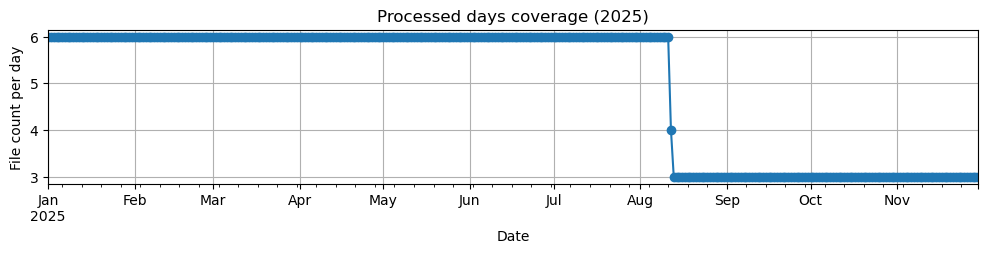

In [4]:
# Check file completeness and rename files based on actual dates in the data.
# This avoids one-day lag and daylight-saving filename issues.
dirs = ["DA", "RT", "FM"]
real_days = []

for d in dirs:
    for filename in glob.glob(os.path.join(d, "*.csv")):
        try:
            df = pd.read_csv(filename)
            df["INTERVALSTARTTIME_GMT"] = pd.to_datetime(df["INTERVALSTARTTIME_GMT"])
            df = df.sort_values("INTERVALSTARTTIME_GMT").reset_index(drop=True)
        except Exception:
            continue

        real_day = df["INTERVALSTARTTIME_GMT"].iloc[0].strftime("%Y%m%d")
        new_filename = os.path.join(d, f"{real_day}_LMP.csv")
        os.rename(filename, new_filename)
        real_days.append(real_day)

all_days = pd.date_range(start=start_date, end=end_date).strftime("%Y%m%d").tolist()
missing_days = set(all_days) - set(real_days)
if missing_days:
    print("Missing days:", sorted(missing_days))
else:
    print(f"All days from {start_date} to {end_date} are covered.")

real_days = sorted([int(day) for day in real_days])
real_days_dt = pd.to_datetime([str(day) for day in real_days], format="%Y%m%d")
df_days = pd.DataFrame({"day": real_days_dt})
counts = df_days["day"].value_counts().sort_index()

plt.figure(figsize=(12, 2))
counts.plot(marker="o")
plt.title(f"Processed days coverage ({year})")
plt.ylabel("File count per day")
plt.xlabel("Date")
plt.grid(True)
plt.show()


In [5]:
# Calculate clean 15-minute LMP prices for DA and FM markets.
# NOTE: 07:00-00:00 GMT corresponds to 00:00 PDT; the downloaded files are aligned to local operating days here.
dates = pd.date_range(start=start_date, end=end_date)
LMP_DA_list = []
LMP_FM_list = []
date_missing = []

for d in dates:
    date_str = d.strftime("%Y%m%d")

    da_files = glob.glob(os.path.join("DA", f"{date_str}_LMP.csv"))
    fm_files = glob.glob(os.path.join("FM", f"{date_str}_LMP.csv"))
    if not da_files or not fm_files:
        date_missing.append(date_str)
        continue

    da = pd.read_csv(da_files[0])
    fm = pd.read_csv(fm_files[0])

    da = da[da["LMP_TYPE"] == "LMP"]
    fm = fm[fm["LMP_TYPE"] == "LMP"]

    da = da.sort_values("INTERVALSTARTTIME_GMT")
    fm = fm.sort_values("INTERVALSTARTTIME_GMT")

    lmp_da = (da["MW"].to_numpy().repeat(4) * 0.001).reshape(96, 1)

    fm_val = fm["VALUE"].to_numpy()
    fm_reshape = fm_val.reshape(-1, 3)
    lmp_fm = (fm_reshape.mean(axis=1) * 0.001).reshape(96, 1)

    df_da_day = pd.DataFrame({
        "Datetime": pd.date_range(start=d, periods=96, freq="15min"),
        "Price($/kWh)": lmp_da.flatten(),
    })
    df_fm_day = pd.DataFrame({
        "Datetime": pd.date_range(start=d, periods=96, freq="15min"),
        "Price($/kWh)": lmp_fm.flatten(),
    })
    LMP_DA_list.append(df_da_day)
    LMP_FM_list.append(df_fm_day)

print("date_missing:", date_missing)
LMP_DA = pd.concat(LMP_DA_list, ignore_index=True)
LMP_FM = pd.concat(LMP_FM_list, ignore_index=True)

LMP_DA.to_csv(f"LMP_DA_{year}_clean.csv", index=False)
LMP_FM.to_csv(f"LMP_FM_{year}_clean.csv", index=False)


date_missing: []


             LMP_DA        LMP_FM
count  32064.000000  32064.000000
mean       0.038562      0.037763
std        0.021836      0.030641
min       -0.036982     -0.064381
25%        0.028915      0.026320
50%        0.043137      0.040220
75%        0.051476      0.049751
max        0.164522      1.033091


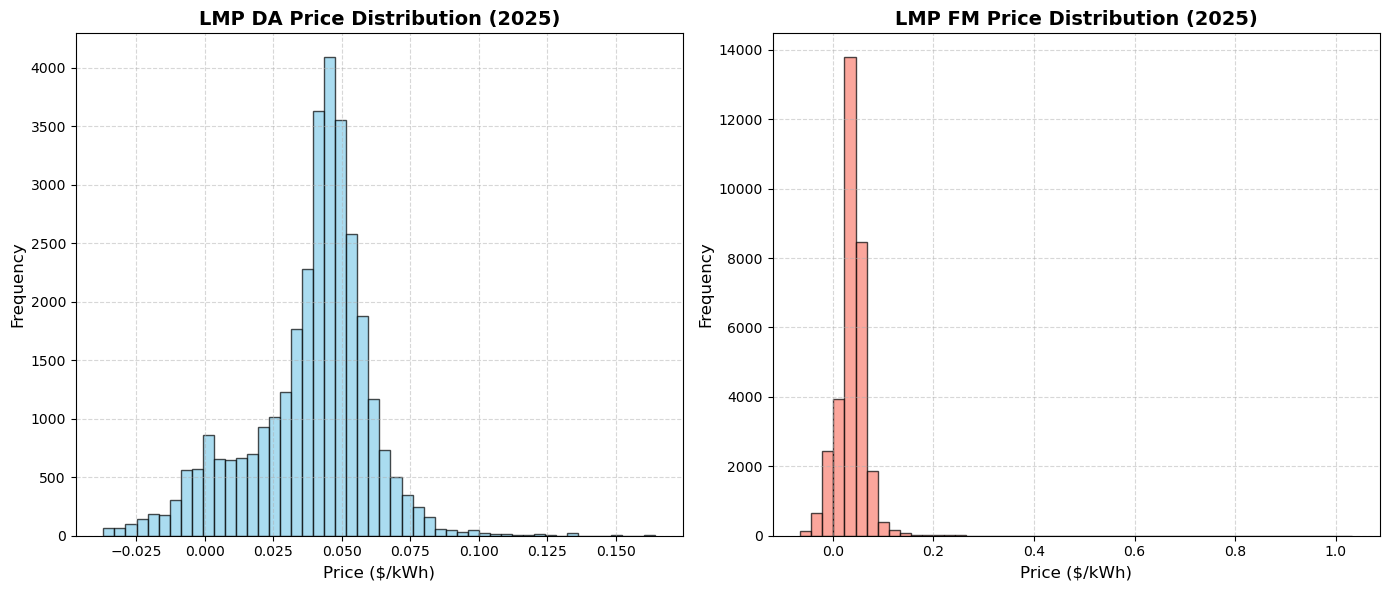

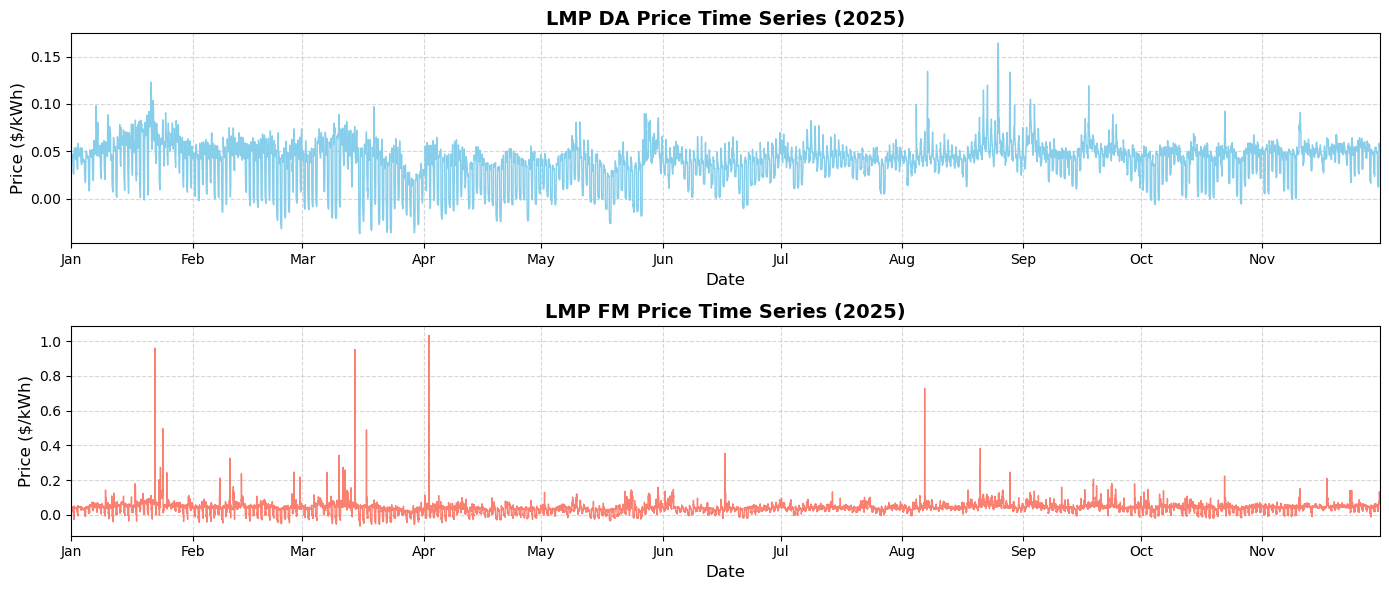

In [6]:
# Show stats and plot DA/FM price distributions and time series.
LMP_DA_stats = LMP_DA["Price($/kWh)"].describe()
LMP_FM_stats = LMP_FM["Price($/kWh)"].describe()
stats_df = pd.DataFrame({
    "LMP_DA": LMP_DA_stats,
    "LMP_FM": LMP_FM_stats,
})
print(stats_df)
stats_df.to_csv(f"LMP_Price_Statistics_{year}.csv")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(LMP_DA["Price($/kWh)"], bins=50, color="skyblue", edgecolor="black", alpha=0.7)
plt.title(f"LMP DA Price Distribution ({year})", fontsize=14, fontweight="bold")
plt.xlabel("Price ($/kWh)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(LMP_FM["Price($/kWh)"], bins=50, color="salmon", edgecolor="black", alpha=0.7)
plt.title(f"LMP FM Price Distribution ({year})", fontsize=14, fontweight="bold")
plt.xlabel("Price ($/kWh)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"LMP_Price_{year}.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(LMP_DA["Datetime"], LMP_DA["Price($/kWh)"], color="skyblue", linewidth=1)
plt.title(f"LMP DA Price Time Series ({year})", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price ($/kWh)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.xlim([LMP_DA["Datetime"].min(), LMP_DA["Datetime"].max()])

plt.subplot(2, 1, 2)
plt.plot(LMP_FM["Datetime"], LMP_FM["Price($/kWh)"], color="salmon", linewidth=1)
plt.title(f"LMP FM Price Time Series ({year})", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price ($/kWh)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.xlim([LMP_FM["Datetime"].min(), LMP_FM["Datetime"].max()])

plt.tight_layout()
plt.savefig(f"LMP_Price_TimeSeries_{year}.png", dpi=300)
plt.show()
